In [1]:
import re
import argparse
from pathlib import Path

# imports de ML e avaliação (podem falhar se os pacotes não estiverem instalados)
try:
    from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
    import torch
except Exception as e:
    MBartForConditionalGeneration = None
    MBart50TokenizerFast = None
    torch = None

# sacrebleu ou fallback
try:
    import sacrebleu
    _have_sacrebleu = True
except Exception:
    _have_sacrebleu = False
    try:
        from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
        _have_nltk_bleu = True
    except Exception:
        _have_nltk_bleu = False

import matplotlib.pyplot as plt

In [2]:
def segment_text(text: str):
    # Divide antes de Proémio ou Capítulo (aceita "Proémio" e "Capítulo" como marcadores)
    pattern = r'(?=(?:Proémio|Capítulo)[\s\S]{0,40}?,\s*n\.\s*\d+|(?<=\n)Proémio|(?<=\n)Capítulo)'
    # fallback: split por linhas que começam com 'Proémio' ou 'Capítulo'
    splits = re.split(r'(?=^(?:Proémio|Capítulo).*$)', text, flags=re.MULTILINE)
    sections = [s.strip() for s in splits if s.strip()]
    return sections

# Função para traduzir lista de seções com mBART
def translate_sections_mbart(sections):
    if MBartForConditionalGeneration is None or MBart50TokenizerFast is None:
        raise RuntimeError('Transformers/torch não estão disponíveis neste ambiente. Instale "transformers" e "torch".')

    model_name = 'facebook/mbart-large-50-many-to-many-mmt'
    print('Carregando modelo', model_name)
    tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
    model = MBartForConditionalGeneration.from_pretrained(model_name)

    # configuração de idiomas
    tokenizer.src_lang = 'it_IT'
    tgt_lang_code = tokenizer.lang_code_to_id.get('pt_XX')
    if tgt_lang_code is None:
        raise RuntimeError('tokenizer não tem o código pt_XX')

    translations = []
    for sec in sections:
        # gerar token de início apropriado forçando o BOS ao idioma alvo
        encoded = tokenizer(sec, return_tensors='pt', truncation=True, max_length=1024)
        forced_bos_id = tokenizer.lang_code_to_id['pt_XX']
        generated = model.generate(**encoded, forced_bos_token_id=forced_bos_id, max_length=1024)
        txt = tokenizer.batch_decode(generated, skip_special_tokens=True)[0]
        translations.append(txt)
    return translations

# Função para round-trip (IT->PT->IT)
def round_trip_back_to_it(pt_sections):
    # usamos o mesmo modelo, agora traduzindo pt_XX -> it_IT
    model_name = 'facebook/mbart-large-50-many-to-many-mmt'
    tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
    model = MBartForConditionalGeneration.from_pretrained(model_name)

    tokenizer.src_lang = 'pt_XX'
    translations_it = []
    for sec in pt_sections:
        encoded = tokenizer(sec, return_tensors='pt', truncation=True, max_length=1024)
        forced_bos_id = tokenizer.lang_code_to_id['it_IT']
        generated = model.generate(**encoded, forced_bos_token_id=forced_bos_id, max_length=1024)
        txt = tokenizer.batch_decode(generated, skip_special_tokens=True)[0]
        translations_it.append(txt)
    return translations_it


In [3]:
# BLEU por seção usando sacrebleu (corpus BLEU) ou nltk (sentence BLEU)
def compute_bleu_scores(references, candidates):
    # both are lists of strings, same length
    scores = []
    if _have_sacrebleu:
        for ref, cand in zip(references, candidates):
            # sacrebleu expects list of references (each a list of refs) and candidates
            bleu = sacrebleu.sentence_bleu(cand, [ref])
            scores.append(bleu.score)
    elif _have_nltk_bleu:
        chencherry = SmoothingFunction()
        for ref, cand in zip(references, candidates):
            ref_tokens = ref.split()
            cand_tokens = cand.split()
            # sentence_bleu returns 0-1; convert to percentage
            try:
                sc = sentence_bleu([ref_tokens], cand_tokens, smoothing_function=chencherry.method2) * 100
            except Exception:
                sc = 0.0
            scores.append(sc)
    else:
        raise RuntimeError('Nenhuma biblioteca de BLEU disponível. Instale sacrebleu ou nltk.')
    return scores

# Plot horizontal bar chart
def plot_horizontal_scores(labels, scores, out_path='bleu_scores.png'):
    fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(labels))))
    y_pos = range(len(labels))
    ax.barh(y_pos, scores)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('BLEU score (%)')
    ax.set_title('Comparação de acertos por tópico (BLEU)')
    plt.tight_layout()
    fig.savefig(out_path)
    print(f'Gráfico salvo em: {out_path}')
    plt.show()


def main(notebook_input_text=None): # Modified: added notebook_input_text parameter
    # O argparse não funciona diretamente no notebook sem simular a linha de comando.
    # Substituímos a leitura de argumentos por variáveis e valores padrão/teste.
    # O usuário deve modificar estas variáveis ou usar a versão CLI do código.

    # --- Variáveis de simulação para o notebook ---
    input_txt_path = None # Defina o caminho para o arquivo IT, e.g., 'meu_texto.txt'
    ref_pt_path = None    # Defina o caminho para a referência PT, e.g., 'ref_pt.txt'
    out_prefix = 'output' # Prefixo para arquivos de saída
    # ----------------------------------------------

    # Simulação da lógica de leitura de argumentos
    class Args:
        def __init__(self, input_txt, ref_pt, out_prefix):
            self.input_txt = input_txt
            self.ref_pt = ref_pt
            self.out_prefix = out_prefix

    args = Args(input_txt_path, ref_pt_path, out_prefix)

    if args.input_txt:
        text = Path(args.input_txt).read_text(encoding='utf-8')
    else:
        # Modified: use notebook_input_text if provided, otherwise raise error or use placeholder
        if notebook_input_text:
            text = notebook_input_text
        else:
            raise ValueError("Por favor, forneça o texto de entrada via 'input_txt_path' ou passe 'notebook_input_text' para a função main().")


    sections = segment_text(text)
    print(f'Encontrei {len(sections)} seções. Exemplo primeira seção:\n', sections[0][:300])

    # Traduzir IT -> PT
    pt_translations = translate_sections_mbart(sections)

    # salvar traduções
    out_trans_file = f'{args.out_prefix}_translations_pt.txt'
    with open(out_trans_file, 'w', encoding='utf-8') as f:
        for s in pt_translations:
            f.write(s + '\n\n')
    print('Traduções salvas em', out_trans_file)

    # Se houver referência em PT, carregar e comparar
    if args.ref_pt:
        ref_text = Path(args.ref_pt).read_text(encoding='utf-8')
        ref_sections = [s.strip() for s in re.split(r'\n\s*\n', ref_text) if s.strip()]
        if len(ref_sections) != len(pt_translations):
            print('Aviso: número de seções na referência difere das seções traduzidas. Tentando alinhar pelos primeiros N...')
            n = min(len(ref_sections), len(pt_translations))
            ref_sections = ref_sections[:n]
            pt_translations = pt_translations[:n]
        scores = compute_bleu_scores(ref_sections, pt_translations)
        labels = [f'Section {i+1}' for i in range(len(scores))]
        plot_horizontal_scores(labels, scores, out_path=f'{args.out_prefix}_bleu_ref.png')
        # exportar CSV simples
        with open(f'{args.out_prefix}_bleu_scores.csv', 'w', encoding='utf-8') as f:
            f.write('section,bleu\n')
            for lab, sc in zip(labels, scores):
                f.write(f'""""""""{lab}""""""",{sc:.2f}\n')
        print('Scores BLEU salvos em CSV.')
    else:
        # Sem referência: rodada de round-trip IT->PT->IT e comparação IT_original x IT_roundtrip
        it_roundtrip = round_trip_back_to_it(pt_translations)
        scores = compute_bleu_scores(sections, it_roundtrip)
        labels = [re.split(r'\n', s, maxsplit=1)[0][:60] for s in sections]
        plot_horizontal_scores(labels, scores, out_path=f'{args.out_prefix}_bleu_roundtrip.png')
        with open(f'{args.out_prefix}_bleu_roundtrip_scores.csv', 'w', encoding='utf-8') as f:
            f.write('section,bleu\n')
            for lab, sc in zip(labels, scores):
                f.write(f'""""""""{lab}""""""",{sc:.2f}\n')
        print('Round-trip BLEU salvo em CSV.')


if __name__ == '__main__':
    # Para executar no notebook, o main() deve ser chamado.
    # Certifique-se de que os pacotes "transformers", "torch" e "sacrebleu" (ou "nltk") estejam instalados.
    # Modificado: Para usar o input_text definido em outra célula, passe-o como argumento.
    # É necessário que a célula que define 'input_text' seja executada primeiro.
    try:
        main(input_text)
    except NameError:
        print("Erro: 'input_text' não está definido. Certifique-se de que a célula que define 'input_text' foi executada.")
        print("Você pode definir 'input_text = \"Seu texto aqui\"' antes de chamar main() ou passar um caminho de arquivo para input_txt_path.")
    except ValueError as e:
        print(f"Erro de Validação: {e}")

Erro: 'input_text' não está definido. Certifique-se de que a célula que define 'input_text' foi executada.
Você pode definir 'input_text = "Seu texto aqui"' antes de chamar main() ou passar um caminho de arquivo para input_txt_path.


Carregando modelo facebook/mbart-large-50-many-to-many-mmt


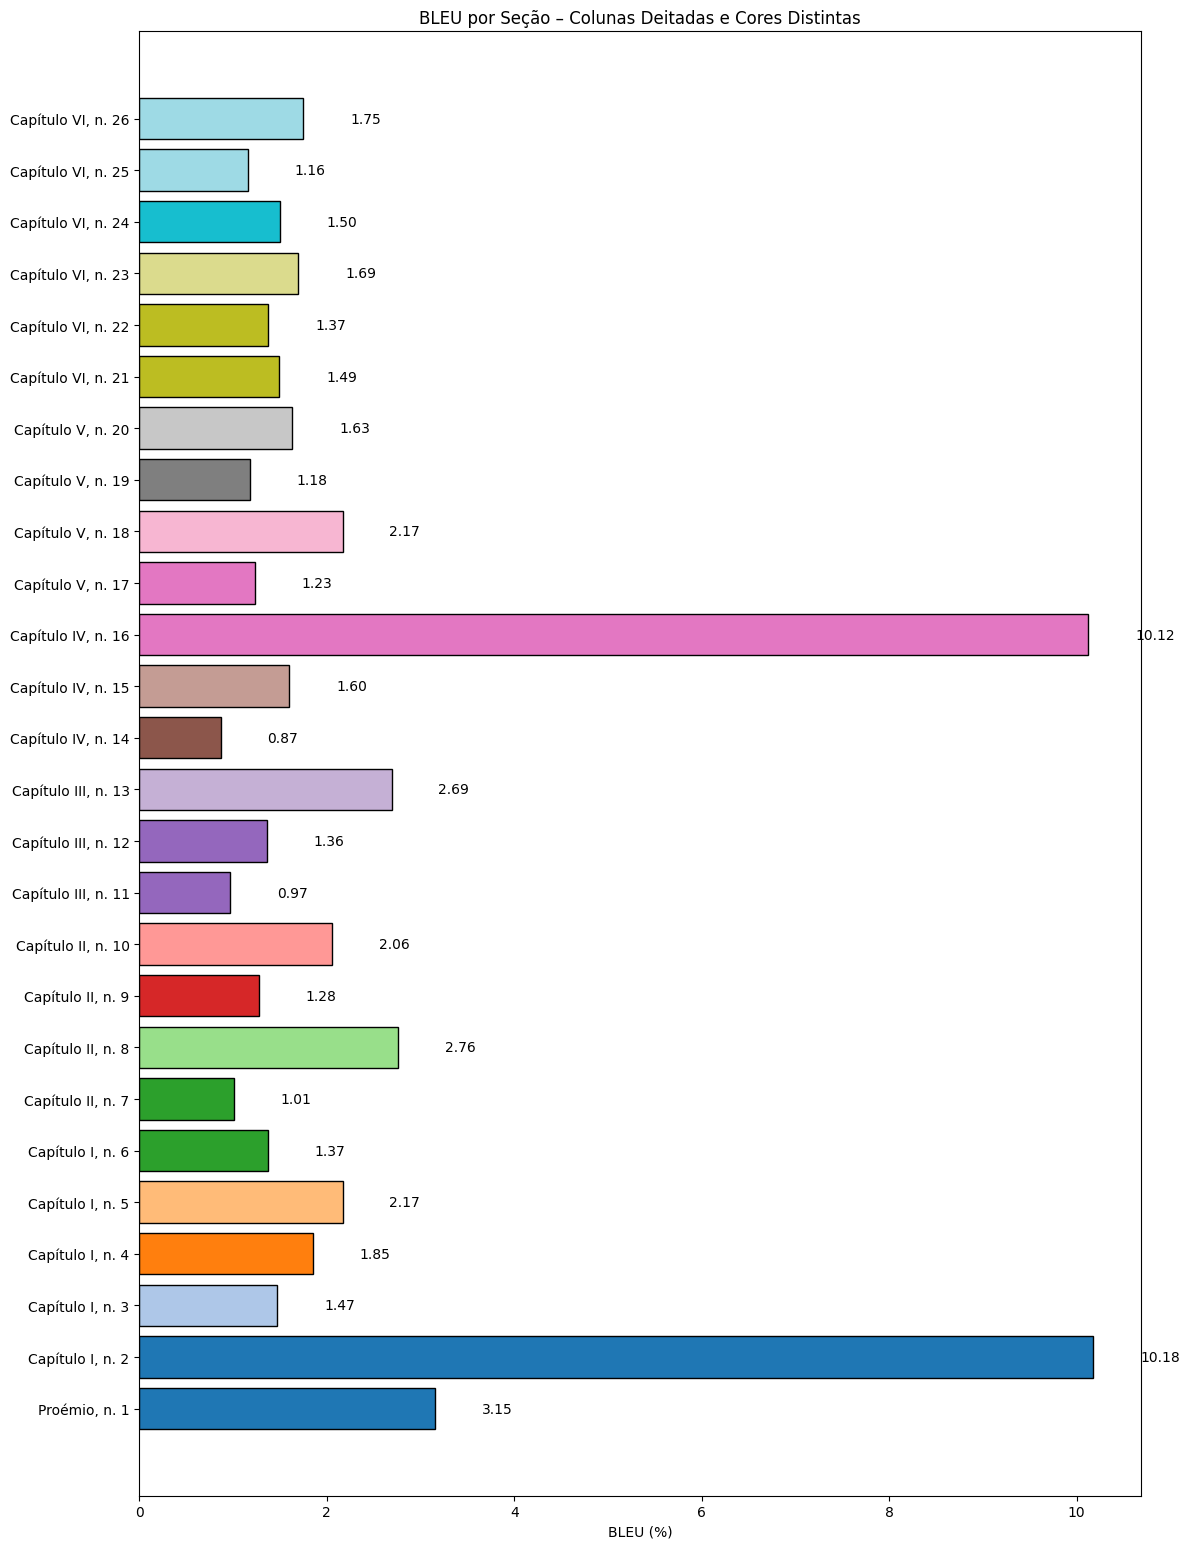

In [5]:
# Copied from cell Zwzu_FrbvYJ
input_text = '''Proémio, n. 1
"Il sacro Concilio, udendo con religiosa attenzione la parola di Dio e proclamandola con ferma fiducia, fa sue queste parole di san Giovanni: «Vi annunziamo la vita eterna, que era presso il Padre e si manifestò a noi: vi annunziamo ciò che abbiamo veduto e udito, affinché anche voi siate in comunione con noi, e la nostra comunione sia col Padre e col Figlio suo Gesù Cristo» (1 Gv 1,2-3)."

"Perciò, seguindo i Concili Tridentino e Vaticano I, esso intende proporre l'autentica dottrina sulla divina Rivelazione e sulla sua trasmissione, affinché, per l'annunzio della salvezza, il mondo intero ascoltando creda, credendo speri, sperando ami."

Capítulo I, n. 2
"Piacque a Dio nella sua bontà e sapienza rivelare se stesso e far conoscere il mistero della sua volontà (cfr. Ef 1,9), mediante il quale gli uomini per mezzo di Cristo, Verbo fatto carne, nello Spirito Santo hanno accesso al Padre e sono resi partecipi della divina natura (cfr. Ef 2,18; 2 Pt 1,4)."

"Con questa rivelazione infatti, Dio invisibile (cfr. Col 1,15; 1 Tm 1,17) nel suo immenso amore parla agli uomini come ad amici (cfr. Es 33,11; Gv 15,14-15) e si intrattiene con essi (cfr. Bar 3,38), per invitarli e ammetterli alla comunione con sé."

"Questa «economia» della Rivelazione avviene con eventi e parole intimamente connessi tra loro, in modo che le opere, compiute da Dio nella storia della salvezza, manifestano e rafforzano la dottrina e le realtà significate dalle parole, e le palavras a loro volta proclamano le opere e chiariscono o mistero in esse contenuto."

"Però la profonda verità, sia riguardo a Dio, sia riguardo alla salvezza degli uomini, per mezzo di questa Rivelazione, risplende a noi in Cristo, que é insieme o mediador e a plenitude de toda a Revelação (2)."

Capítulo I, n. 3
"Dio, o qual cria e conserva todas as coisas pelo Verbo (cfr. Jo 1,3), oferece aos homens nas coisas criadas um perene testemunho de Si (cfr. Rm 1,19-20). Além disso, querendo abrir o caminho da salvação sobrenatural, desde o princípio manifestou-se aos Progenitores."

"Depois da sua queda, com a promessa da redenção, levantou-os à esperança da salvação (cfr. Gn 3,15), e sem interrupção teve cuidado do gênero humano, para dar a vida eterna a todos aqueles que procuram a salvação com a perseverança nas boas obras (cfr. Rm 2,6-7)."

"A seu tempo chamou Abraão, para fazer dele um povo grande (cfr. Gn 12,2), povo que depois dos Patriarcas instruiu por meio de Moisés e dos profetas, para que O reconhecesse como o único Deus vivo e verdadeiro, pai providente e justo juiz, e esperasse o Salvador prometido; e assim preparou através dos séculos o caminho para o Evangelho."

Capítulo I, n. 4
"Depois de ter a várias vezes e de vários modos falado por meio dos profetas, « Deus ultimamente, nestes dias, falou-nos por meio do Filho » (Hb 1,1-2)."

"Mandou de facto o seu Filho, isto é, o Verbo eterno, que ilumina todos os homens, para que habitasse entre os homens e a eles explicasse o íntimo de Deus (cfr. Jo 1,1-18)."

"Jesus Cristo, Verbo feito carne, enviado como «homem aos homens» (3), «fala as palavras de Deus» (Jo 3,34) e cumpre a obra de salvação que o Pai lhe tinha confiado (cfr. Jo 5,36; 17,4)."

"Por isso quem O vê, vê também o Pai (cfr. Jo 14,9). Ele, com toda a sua presença e manifestação, com as palavras e com as obras, com os sinais e com os milagres, e especialmente com a sua morte e gloriosa ressurreição, e finalmente com o envio do Espírito de verdade, cumpre e completa a Revelação e a confirma com o testemunho divino, ou seja, que Deus está connosco para nos libertar das trevas do pecado e da morte e para nos ressuscitar para a vida eterna."

"Por isso a Economia cristã, enquanto Aliança nova e definitiva, nunca passará, e não se deverá esperar nenhuma outra revelação pública antes da manifestação gloriosa do Senhor nosso Jesus Cristo (cfr. 1 Tm 6,14; Tt 2,13)."

Capítulo I, n. 5
"A Deus que revela é devida «a obediência da fé» (Rm 16,26; cfr. Rm 1,5; 2 Cor 10,5-6)."

"Com a fé de facto o homem abandona-se inteiramente a Deus livremente, prestando «com o intelecto e com a vontade a obediência plena a Deus que revela» (4) e dando o seu assentimento voluntário à revelação feita por Ele."

"Para prestar esta fé, é necessária a graça de Deus que previne e socorre, e os auxílios interiores do Espírito Santo, o qual mova o coração e o dirija a Deus, abra os olhos da mente e dê «a todos suavidade no consentir e no crer à verdade» (5)."

"Para que a inteligência da Revelação se torne cada vez mais profunda, o mesmo Espírito Santo aperfeiçoa continuamente a fé por meio dos seus dons."

Capítulo I, n. 6
"Com a divina Revelação Deus quis manifestar e comunicar-se a Si mesmo e os decretos da sua vontade para a salvação dos homens, «para os tornar participantes dos bens divinos, que transcendem absolutamente a inteligência da mente humana» (6)."

"O santo Concílio professa que «Deus, princípio e fim de todas as coisas, pode ser conhecido com certeza com a luz natural da razão humana a partir das coisas criadas» (cfr. Rm 1,20);"

"mas ensina também que é mérito da Revelação divina se «tudo aquilo que nas coisas divinas não é por si inacessível à razão humana, pode, também na atual condição do gênero humano, ser conhecido por todos facilmente, com firme certeza e sem mistura de erro» (7)."

Capítulo II, n. 7
"Deus com suma benignidade dispôs que quanto Ele tinha revelado para a salvação de todas as gentes, permanecesse para sempre íntegro e fosse transmitido a todas as gerações."

"Por isso Cristo Senhor, no qual se cumpre toda a Revelação do sumo Deus (cfr. 2 Cor 1,20; 3,16-4,6), depois de ter levado a cabo em Si toda a verdade de Deus pregou de pessoa (1), mandou aos apóstolos que pregassem a todos, como a fonte de toda a verdade salvífica e de toda a regra moral, aquele Evangelho que ele antes tinha prometido por meio dos profetas e que depois tinha cumprido e promulgado de pessoa, comunicando assim a eles os dons divinos."

"Isto foi fielmente executado, seja pelos apóstolos, os quais na pregação oral, com os exemplos e as instituições transmitiram seja o que tinham recebido da boca do Cristo vivendo com Ele e observando-O agir, seja o que tinham aprendido das sugestões do Espírito Santo, seja daqueles apóstolos ou de homens da sua esfera, os quais, por inspiração do mesmo Espírito Santo, puseram por escrito a mensagem da salvação (2)."

"Os apóstolos depois, para que o Evangelho se conservasse sempre íntegro e vivo na Igreja, deixaram como seus sucessores os bispos, a eles «confiando o seu próprio lugar de mestres» (3)."

"Esta sagrada Tradição e a sagrada Escritura de ambos os Testamentos são portanto como um espelho no qual a Igreja peregrina na terra contempla Deus, do qual tudo recebe, até que chegue a vê-Lo face a face, como Ele é (cfr. 1 Jo 3,2)."

Capítulo II, n. 8
"Assim a pregação apostólica, que é expressa de modo especial nos livros inspirados, devia com uma sucessão ininterrupta conservar-se até ao fim dos tempos."

"Por isso os apóstolos, transmitindo o que eles mesmos tinham recebido, admoestam os fiéis a ater-se às tradições que tinham aprendido ou com a palavra, ou por escrito (cfr. 2 Ts 2,15), e a combater pela fé que a eles tinha sido transmitida uma vez por todas (cfr. Judas 3)(4)."

"Ora, o que foi transmitido pelos apóstolos, compreende tudo quanto contribui para a santidade de vida e para o incremento da fé no povo de Deus; e assim a Igreja, na sua doutrina, na sua vida e no seu culto, perpetua e transmite a todas as gerações tudo o que ela é, tudo o que ela crê."

"Esta Tradição, que tem origem nos apóstolos, progride na Igreja com a assistência do Espírito Santo (5)."

"Cresce de facto a compreensão, tanto das coisas quanto das palavras transmitidas, seja com a contemplação e o estudo dos crentes, que as meditam nos seus corações (cfr. Lc 2,19 e 51), seja com a inteligência interior, que eles provam das coisas espirituais, seja pela pregação daqueles que com a sucessão episcopal receberam um carisma seguro de verdade."

"A Igreja, isto é, no decorrer dos séculos, tende incessantemente à plenitude da verdade divina, até que nela cheguem a cumprimento as palavras de Deus."

"As asserções dos santos Padres atestam a presença vivificadora desta Tradição, cujos tesouros se derramam na prática e na vida da Igreja crente e orante."

"Por meio desta mesma Tradição a Igreja conhece o cânone completo dos livros sagrados, e as mesmas sagradas Escrituras nela são compreendidas mais profundamente e tornadas incessantemente operantes;"

"e assim Deus, o qual falou no passado, não cessa de conversar com a Esposa do seu Filho dileto;"

"e o Espírito Santo, por meio do qual a voz viva do Evangelho ressoa na Igreja, e por meio desta no mundo, introduz os crentes em toda a verdade e faz com que neles resida abundantemente a palavra de Cristo (cfr. Col 3,16)."

Capítulo II, n. 9
"A sagrada Tradição e a sagrada Escritura são, portanto, estreitamente conectadas e comunicantes entre si."

"De facto, ambas nascem da mesma fonte divina, formam de certo modo uma coisa só e tendem ao mesmo fim."

"A sagrada Escritura de facto é a palavra de Deus na medida em que é posta por escrito sob a inspiração do Espírito divino."

"Quanto à sagrada Tradição, ela transmite integralmente a palavra de Deus, confiada por Cristo Senhor e pelo Espírito Santo aos Apóstolos, aos seus sucessores, para que estes, iluminados pelo Espírito de verdade, na sua pregação a conservem fielmente, a exponham e a difundam."

"Disso se conclui que a Igreja não tira a certeza sobre todas as coisas reveladas da só sagrada Escritura."

"Por isso uma e outra devem ser aceitas e veneradas com igual sentimento de piedade e de reverência (6)."

Capítulo II, n. 10
"A sagrada Tradição e a sagrada Escritura constituem um só sagrado depósito da palavra de Deus confiado à Igreja;"

"ao aderir a ele, todo o povo santo, unido aos seus Pastores, persevera constante no ensinamento dos Apóstolos e na comunhão, na fração do pão e na oração (cfr. At 2,42 gr.), de modo que ao reter, praticar e professar a fé transmitida, se crie uma singular concórdia de bispos e de fiéis (7)."

"O ofício depois de interpretar autenticamente a palavra de Deus escrita ou transmitida, é confiado ao só Magistério vivo da Igreja (8), cuja autoridade é exercida em nome de Jesus Cristo (9)."

"O Magistério, todavia, não é superior à palavra de Deus, mas a serve, ensinando somente o que foi transmitido, enquanto, por divino mandato e com a assistência do Espírito Santo, piamente a escuta, santamente a guarda e fielmente a expõe, tirando deste único depósito da fé tudo o que propõe para crer como divinamente revelado."

"É claro, portanto, que a sagrada Tradição, a sagrada Escritura e o Magistério da Igreja, por sapientíssima disposição de Deus, estão entre si tão conectados e conjuntados que nenhum deles subsiste sem os outros, e todos juntos, cada um a seu modo, sob a ação do Espírito Santo, contribuem eficazmente para a salvação das almas."

Capítulo III, n. 11
"As verdades divinamente reveladas, que nos livros da sagrada Escritura são contidas e expressas, foram escritas por inspiração do Espírito Santo."

"A santa Mãe Igreja, segundo a fé dos Apóstolos, considera sagrados e canônicos todos os livros seja do Antigo que do Novo Testamento com todas as suas partes, porque escritos por inspiração do Espírito Santo (cfr. Jo 20,31; 2 Tm 3,16; 2 Pe 1,19-21; 3,15-16), têm Deus por autor e como tais foram confiados à própria Igreja (1)."

"Para a composição dos livros sagrados, Deus escolheu homens dos quais se serviu no posse das suas faculdades e capacidades, para que, agindo Ele neles e por eles (2), escrevessem como verdadeiros autores, todas e somente aquelas coisas que Ele queria (3)."

"Pelo facto de, portanto, tudo aquilo que os autores inspirados ou hagiógrafos asseveram é para ser considerado asseverado pelo Espírito Santo, disso se conclui que os livros da Escritura ensinam com certeza, fielmente e sem erro a verdade que Deus para a nossa salvação quis que fosse entregue nas sagradas Letras (4)."

"Por isso «toda a Escritura é inspirada por Deus e útil para ensinar, para convencer, para corrigir, para educar à justiça, para que o homem de Deus seja perfeito, pronto para toda a boa obra» (2 Tm 3,16-17 gr.)."

Capítulo III, n. 12
"Deus na sagrada Escritura falou por meio de homens e à maneira humana (5). Para o intérprete da sagrada Escritura, portanto, para conhecer o que Deus quis comunicar-nos, é preciso procurar com atenção o que os hagiógrafos verdadeiramente quiseram significar e a Deus aprouve manifestar com as suas palavras."

"Para descobrir a intenção dos hagiógrafos, deve-se ter em conta entre outras coisas também os «géneros literários»."

"A verdade, de facto, é diversamente proposta e expressa em textos de vários modos históricos, ou proféticos, ou poéticos, ou em outros modos de dizer."

"É necessário que o intérprete procure o sentido que o hagiógrafo em determinadas circunstâncias, segundo as condições do seu tempo e da sua cultura, e servindo-se dos géneros literários então em uso, intencionava expressar e de facto expressou (6)."

"Para compreender de facto exatamente o que o autor sagrado quis afirmar, deve-se ter em conta convenientemente seja os modos nativos de sentir, de exprimir-se e de contar vigentes ao tempo do hagiógrafo, seja os que naquele tempo eram habitualmente em uso nas relações humanas (7)."

"Mas porque a sagrada Escritura deve ser lida e interpretada com o mesmo Espírito com o qual foi escrita (8), para tirar com exatidão o sentido dos textos sagrados, deve-se prestar não menor diligência ao conteúdo e à unidade de toda a Escritura, tendo devido em conta a viva Tradição de toda a Igreja e a analogia da fé."

"É tarefa dos exegetas trabalhar segundo estas regras, para uma mais profunda inteligência e exposição do sentido da sagrada Escritura, para que por meio de estudos de algum modo preparatórios, amadureça o juízo da Igreja."

"Tudo aquilo de facto que concerne o modo de interpretar a Escritura, é submetido em última instância ao juízo da Igreja, que cumpre o divino mandato e ministério de guardar e interpretar a palavra de Deus (9)."

Capítulo III, n. 13
"Portanto na sagrada Escritura, permanecendo firme a verdade e a santidade de Deus, manifesta-se a admirável «condescendência» da Sabedoria eterna, «para que aprendamos qual inefável benignidade de Deus e"

"quanta solicitude Ele teve pela nossa natureza» (10)."

"As palavras de Deus, de facto, expressas com línguas humanas, tornaram-se semelhantes ao falar humano, assim como já o Verbo do eterno Pai, tendo assumido a carne da humana fraqueza, tornou-se semelhante aos homens."

Capítulo IV, n. 14
"Deus com sumo amor, querendo e preparando a salvação de todo o género humano, com singular desígnio escolheu um povo, ao qual confiar as suas promessas."

"Depois de ter estabelecido uma aliança com Abraão (cfr. Gn 15,18), e por meio de Moisés com o povo de Israel (cfr. Ex 24,8), a este povo eleito revelou-se como o único Deus vivo e verdadeiro, de modo que Israel pudesse conhecer por experiência o plano de Deus no que diz respeito aos homens, e o compreendesse com clareza e cada vez mais profundamente através da palavra do mesmo Deus que falava pela boca dos profetas, e o difundisse de modo mais amplo entre as gentes (cfr. Sal 21,28-29; 95,1-3; Is 2,1-4; Jr 3,17)."

"A economia da salvação, anunciada previamente, narrada e explicada pelos autores sagrados, encontra-se nos livros do Antigo Testamento como verdadeira palavra de Deus."

"Por isso tais livros divinamente inspirados conservam um valor perene: «Tudo aquilo de facto que foi escrito, foi escrito para a nossa instrução, para que mediante a paciência e a consolação das Escrituras, tivéssemos a esperança» (Rm 15,4)."

Capítulo IV, n. 15
"A economia do Antigo Testamento era sobretudo ordenada a preparar, a anunciar profeticamente (cfr. Lc 24,44; Jo 5,39; 1 Pe 1,10) e a significar com várias figuras (cfr. 1 Cor 10,11) o advento de Cristo, redentor universal, e do reino messiânico."

"Os livros do Antigo Testamento, segundo a condição do género humano antes do tempo da salvação realizada por Cristo, manifestam a todos o conhecimento de Deus e do homem e os modos com que Deus justo e misericordioso trata os homens."

"Estes livros, embora contenham também coisas imperfeitas e caducas, demonstram todavia uma verdadeira pedagogia divina (1)."

"Por isso os fiéis devem acolher com devoção estes livros, os quais exprimem o vivo sentido de Deus, e nos quais se encontram sublimes doutrinas sobre Deus, salutares ensinamentos sobre a vida do homem e admiráveis tesouros de orações, e finalmente nos quais está escondido o mistério da nossa salvação."

Capítulo IV, n. 16
"Por isso Deus, o inspirador e o autor dos livros de um e de outro Testamento, dispôs sabiamente que o Novo fosse escondido no Antigo e o Antigo fosse revelado no Novo (2)."

"Contudo, de facto, Cristo fundou a Nova Aliança no seu sangue (cfr. Lc 22,20; 1 Cor 11,25), todavia os livros do Antigo Testamento, integralmente assumidos na pregação evangélica (3), adquirem e manifestam o seu pleno significado no Novo Testamento (cfr. Mt 5,17; Lc 24,27; Rm 16,25-26; 2 Cor 3,14-16), que eles por sua vez iluminam e explicam."

Capítulo V, n. 17
"A palavra de Deus, que é poder de Deus para a salvação de quem crê (cfr. Rm 1,16), apresenta-se e manifesta a sua força de modo eminente nos escritos do Novo Testamento."

"Quando de facto chegou a plenitude dos tempos (cfr. Gl 4,4), o Verbo fez-se carne e habitou entre nós cheio de graça e de verdade (cfr. Jo 1,14)."

"Cristo estabeleceu o reino de Deus sobre a terra, manifestou com obras e palavras o Pai seu e a Si mesmo, e levou a cumprimento a obra sua com a morte, a ressurreição e a gloriosa ascensão, e com o envio do Espírito Santo."

"Elevado da terra, Ele atrai todos a Si (cfr. Jo 12,32 gr.), Ele que só tem palavras de vida eterna (cfr. Jo 6,68)."

"Este mistério, porém, não foi revelado às outras gerações, como agora foi revelado aos seus santos apóstolos e aos profetas no Espírito Santo (cfr. Ef 3,4-6 gr.), para que pregassem o Evangelho, suscitassem a fé em Jesus Cristo Senhor e reunissem a Igreja."

"De todas estas coisas os escritos do Novo Testamento apresentam um testemunho perene e divino."

Capítulo V, n. 18
"A ninguém escapa que entre todas as Escrituras, também do Novo Testamento, os Evangelhos possuem uma merecida superioridade, enquanto constituem o principal testemunho relativo à vida e à doutrina do Verbo encarnado, nosso Salvador."

"A Igreja considerou e considera sempre e em todo o lugar que os quatro Evangelhos são de origem apostólica."

"De facto, o que os apóstolos por mandato de Cristo pregaram, em seguida, por inspiração do Espírito Santo, foi pelos mesmos e por homens da sua esfera transmitido em escritos, que são o fundamento da fé, isto é, o Evangelho quadriforme segundo Mateus, Marcos, Lucas e João (1)."

Capítulo V, n. 19
"A santa Mãe Igreja considerou e considera com firmeza e com a máxima constância que os quatro Evangelhos, dos quais afirma sem hesitação a historicidade, transmitem fielmente as coisas que Jesus Filho de Deus, durante a sua vida entre os homens, efetivamente operou e ensinou para a sua salvação eterna, até ao dia em que foi assunção ao céu (cfr. At 1,1-2)."

"Os apóstolos depois, após a Ascensão do Senhor, transmitiram aos seus ouvintes o que Ele tinha dito e feito, com aquela mais completa inteligência das coisas, da qual eles, instruídos pelos eventos gloriosos de Cristo e iluminados pelo Espírito de verdade (2), desfrutavam (3)."

"Os autores sagrados, depois, escreveram os quatro Evangelhos, escolhendo algumas coisas entre as muitas transmitidas por via oral ou já por escrito, fazendo delas uma síntese, ou explicando-as com referência à situação das Igrejas, conservando finalmente o caráter de pregação, sempre, porém, de modo a referir sobre Jesus coisas verdadeiras e sinceras (4)."

"Eles, de facto, tirando seja das suas próprias recordações seja do testemunho daqueles «que desde o princípio foram testemunhas oculares e ministros da palavra», escreveram com a intenção de nos fazer conhecer a «verdade» (cfr. Lc 1,2-4) dos ensinamentos que recebemos."

Capítulo V, n. 20
"O cânone do Novo Testamento, além dos quatro Evangelhos, contém também as cartas de São Paulo e outros escritos apostólicos, compostos por inspiração do Espírito Santo; estes escritos, por sábia disposição de Deus, confirmam tudo o que diz respeito a Cristo Senhor, explicam ulteriormente a sua autêntica doutrina, fazem conhecer o poder salvífico da obra divina de Cristo, narram os inícios da Igreja e a sua admirável difusão no mundo e preanunciam a sua gloriosa consumação."

"O Senhor Jesus, de facto, assistiu os seus apóstolos como tinha prometido (cfr. Mt 28,20) e enviou-lhes o Espírito consolador, o qual os devia introduzir na plenitude da verdade (cfr. Jo 16,13)."

Capítulo VI, n. 21
"A Igreja sempre venerou as divinas Escrituras como venera o próprio Corpo de Cristo, não deixando nunca, sobretudo na sagrada Liturgia, de nutrir-se do pão da vida da mesa seja da palavra de Deus que do Corpo de Cristo, e de o oferecer aos fiéis."

"Considerou-as sempre, e as considera ainda, juntamente com a sagrada Tradição, como regra suprema da própria fé; elas, de facto, inspiradas como são por Deus e redigidas uma vez para sempre, comunicam de modo imutável a palavra do mesmo Deus, e fazem ressoar nas palavras dos profetas e dos apóstolos a voz do Espírito Santo."

"É necessário, por isso, que toda a pregação eclesiástica, como a própria religião cristã, seja nutrida e regulada pela sagrada Escritura."

"Nos livros sagrados, de facto, o Pai que está nos céus vem com muita amorosidade ao encontro dos seus filhos e entra em conversação com eles;"

"na palavra de Deus, depois, está ínsita uma tão grande eficácia e poder, de ser sustento e vigor da Igreja, e para os filhos da Igreja a força da sua fé, o alimento da alma, a fonte pura e perene da vida espiritual."

"Por isso devem-se referir de modo todo especial à sagrada Escritura as palavras: «Viva e eficaz é a palavra de Deus» (Hb 4,12), «que tem o poder de edificar e de dar a herança com todos os santificados» (At 20,32; cfr. 1 Ts 2,13)."

Capítulo VI, n. 22
"É necessário que os fiéis tenham largo acesso à sagrada Escritura."

"Por este motivo a Igreja desde os seus inícios fez sua a antiquíssima tradução grega do Antigo Testamento, dita dos Setenta, e tem sempre em honra as outras versões orientais e as versões latinas, particularmente aquela que é chamada Vulgata."

"Pois, porém, a palavra de Deus deve estar à disposição de todos em todo o tempo, a Igreja com materna solicitude cuida que se façam traduções apropriadas e corretas nas várias línguas, de preferência dos textos originais dos sagrados livros."

"Se, por uma razão de oportunidade e com a aprovação da autoridade da Igreja, estas traduções forem feitas em colaboração com os irmãos separados, poderão ser usadas por todos os cristãos."

Capítulo VI, n. 23
"A Esposa do Verbo encarnado, a Igreja, instruída pelo Espírito Santo, preocupa-se em alcançar uma inteligência cada vez mais profunda das sagradas Escrituras, para poder nutrir continuamente os seus filhos com as divinas palavras; por isso ela favorece com razão também o estudo dos santos Padres do Oriente e do Ocidente e das sagradas liturgias."

"Os exegetas católicos, e os outros cultores de sagrada teologia, colaborando com zelo e sob a vigilância do sagrado magistério, esforcem-se por estudar e explicar com os oportunos subsídios as divinas Letras, de modo que o maior número possível de ministros da palavra divina sejam capazes de oferecer com fruto ao povo de Deus o alimento das Escrituras, que ilumine a mente, corrobore as vontades e acenda os corações dos homens ao amor de Deus (1)."

"O santo Concílio encoraja os filhos da Igreja que cultivam as ciências bíblicas, a que continuem até ao fim o trabalho felizmente encetado com ardor sempre renovado e segundo o sentido da Igreja (2)."

Capítulo VI, n. 24
"A sagrada teologia baseia-se como em um fundamento perene na palavra de Deus escrita, inseparável da sagrada Tradição; nela se consolida vigorosamente e se rejuvenesce sempre, perscrutando à luz da fé toda a verdade encerrada no mistério de Cristo."

"As sagradas Escrituras contêm a palavra de Deus e, porque inspiradas, são verdadeiramente palavra de Deus, seja por isso o estudo das sagradas páginas como a alma da sagrada teologia (3)."

"Também o ministério da palavra, ou seja, a pregação pastoral, a catequese e todo o tipo de instrução cristã, em que a homilia litúrgica deve ter um lugar privilegiado, encontra nesta mesma palavra da Escritura um alimento saudável e um santo vigor."

Capítulo VI, n. 25
"É necessário, por isso, que todos os clérigos, e sobretudo os sacerdotes de Cristo e os outros que, como os diáconos e os catequistas, atendem legitimamente ao ministério da palavra, conservem um contacto contínuo com as Escrituras mediante uma espiritual leitura assídua e um estudo cuidadoso, para que não se torne «um vão pregador da palavra de Deus por fora aquele que não a escuta dentro de si» (4), enquanto deve participar aos fiéis a ele confiados as superabundantes riquezas da palavra divina, especialmente na sagrada Liturgia."

"Igualmente o santo Concílio exorta com ardor e insistência todos os fiéis, sobretudo os religiosos, a aprender «a sublime ciência de Jesus Cristo» (Fil 3,8) com a frequente leitura das divinas Escrituras. «A ignorância das Escrituras de facto é ignorância de Cristo» (5)."

"Aproximem-se eles de bom grado do sagrado texto, seja mediante a sagrada Liturgia, que é impregnada de palavras divinas, seja mediante a pia leitura, seja por meio das iniciativas adequadas a tal fim e de outros subsídios, que com a aprovação e o cuidado dos Pastores da Igreja, louvavelmente hoje se difundem por toda a parte."

"Recordem-se, porém, que a leitura da sagrada Escritura deve ser acompanhada pela oração, para que se estabeleça o colóquio entre Deus e o homem; pois «a Ele falamos quando oramos; a Ele escutamos, quando lemos os oráculos divinos» (6)."

"Compete aos sagrados Pastores, «depositários da doutrina apostólica» (7), instruir oportunamente os fiéis a eles confiados sobre o reto uso dos livros divinos, de modo particular do Novo Testamento e em primeiro lugar dos Evangelhos."

"E isso por meio de traduções dos sagrados textos; estas devem ser munidas das notas necessárias e verdadeiramente suficientes, para que os filhos da Igreja se familiarizem com segurança e proveito com as sagradas Escrituras e se embebam do seu espírito."

"Além disso, preparem-se edições da sagrada Escritura fornecidas de idóneas anotações, para uso também dos não cristãos e adaptadas à sua situação; seja os Pastores de almas, seja os cristãos de qualquer estado terão o cuidado de as difundir com zelo e prudência."

Capítulo VI, n. 26
"Deste modo, portanto, com a leitura e o estudo dos sagrados livros « a palavra de Deus cumpra a sua corrida e seja glorificada» (2 Ts 3,1), e o tesouro da revelação, confiado à Igreja, encha cada vez mais o coração dos homens."

"Como da assídua frequência do mistério eucarístico se acresce a vida da Igreja, assim é lícito esperar novo impulso à vida espiritual do acrescido veneração pela palavra de Deus, que «permanece em eterno» (Is 40,8; cfr. 1 Pe 1,23-25)."'''

# Copied from cell GpB_nFY8vlcs
def segment_text(text: str):
    # Divide antes de Proémio ou Capítulo (aceita "Proémio" e "Capítulo" como marcadores)
    pattern = r'(?=(?:Proémio|Capítulo)[\s\S]{0,40}?|(?<=\n)Proémio|(?<=\n)Capítulo)'
    # fallback: split por linhas que começam com 'Proémio' ou 'Capítulo'
    splits = re.split(r'(?=^(?:Proémio|Capítulo).*$)', text, flags=re.MULTILINE)
    sections = [s.strip() for s in splits if s.strip()]
    return sections

# Função para traduzir lista de seções com mBART
def translate_sections_mbart(sections):
    if MBartForConditionalGeneration is None or MBart50TokenizerFast is None:
        raise RuntimeError('Transformers/torch não estão disponíveis neste ambiente. Instale "transformers" e "torch".')

    model_name = 'facebook/mbart-large-50-many-to-many-mmt'
    print('Carregando modelo', model_name)
    tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
    model = MBartForConditionalGeneration.from_pretrained(model_name)

    # configuração de idiomas
    tokenizer.src_lang = 'it_IT'
    tgt_lang_code = tokenizer.lang_code_to_id.get('pt_XX')
    if tgt_lang_code is None:
        raise RuntimeError('tokenizer não tem o código pt_XX')

    translations = []
    for sec in sections:
        # gerar token de início apropriado forçando o BOS ao idioma alvo
        encoded = tokenizer(sec, return_tensors='pt', truncation=True, max_length=1024)
        forced_bos_id = tokenizer.lang_code_to_id['pt_XX']
        generated = model.generate(**encoded, forced_bos_token_id=forced_bos_id, max_length=1024)
        txt = tokenizer.batch_decode(generated, skip_special_tokens=True)[0]
        translations.append(txt)
    return translations

# Função para round-trip (IT->PT->IT)
def round_trip_back_to_it(pt_sections):
    # usamos o mesmo modelo, agora traduzindo pt_XX -> it_IT
    model_name = 'facebook/mbart-large-50-many-to-many-mmt'
    tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
    model = MBartForConditionalGeneration.from_pretrained(model_name)

    tokenizer.src_lang = 'pt_XX'
    translations_it = []
    for sec in pt_sections:
        encoded = tokenizer(sec, return_tensors='pt', truncation=True, max_length=1024)
        forced_bos_id = tokenizer.lang_code_to_id['it_IT']
        generated = model.generate(**encoded, forced_bos_token_id=forced_bos_id, max_length=1024)
        txt = tokenizer.batch_decode(generated, skip_special_tokens=True)[0]
        translations_it.append(txt)
    return translations_it

# Copied from cell r4gp3mVZvLU1
# BLEU por seção usando sacrebleu (corpus BLEU) ou nltk (sentence BLEU)
def compute_bleu_scores(references, candidates):
    # both are lists of strings, same length
    scores = []
    if _have_sacrebleu:
        for ref, cand in zip(references, candidates):
            # sacrebleu expects list of references (each a list of refs) and candidates
            bleu = sacrebleu.sentence_bleu(cand, [ref])
            scores.append(bleu.score)
    elif _have_nltk_bleu:
        chencherry = SmoothingFunction()
        for ref, cand in zip(references, candidates):
            ref_tokens = ref.split()
            cand_tokens = cand.split()
            # sentence_bleu returns 0-1; convert to percentage
            try:
                sc = sentence_bleu([ref_tokens], cand_tokens, smoothing_function=chencherry.method2) * 100
            except Exception:
                sc = 0.0
            scores.append(sc)
    else:
        raise RuntimeError('Nenhuma biblioteca de BLEU disponível. Instale sacrebleu ou nltk.')
    return scores

# -----------------------------
# Original code for plotting
# -----------------------------

import numpy as np # Adicionado: Importar numpy

# Replicate the logic to get sections and bleu_scores
sections = segment_text(input_text)
pt_translations = translate_sections_mbart(sections)
bleu_scores = compute_bleu_scores(sections, round_trip_back_to_it(pt_translations))

# Criar rótulos curtos para o eixo Y (exibe só o título da seção)
labels = []
for sec in sections:
    # pega até o primeiro salto de linha ou os 60 primeiros caracteres
    title = sec.split("\n")[0][:60]
    labels.append(title)

scores = bleu_scores  # now defined

# Gera paleta de cores (uma cor por barra)
colors = plt.cm.tab20(np.linspace(0, 1, len(scores)))

# Plot
plt.figure(figsize=(12, 0.6 * len(labels)))
y_pos = np.arange(len(labels))

plt.barh(y_pos, scores, color=colors, edgecolor="black")
plt.yticks(y_pos, labels)
plt.xlabel("BLEU (%)")
plt.title("BLEU por Seção – Colunas Deitadas e Cores Distintas")

# Adiciona valores numéricos ao lado das barras
for i, v in enumerate(scores):
    plt.text(v + 0.5, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()